# Start

In [1]:
import torch
import torch.nn.functional as F
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from wavegen import generate_multiwave
from ldst import waves_residual_split, reconstruct_y


device = 'cuda'

# Run

## Generate Multiwave

In [2]:
x, y, x_date, waves, linear_component, exponential_component = generate_multiwave(9)
x_tensor = torch.tensor(x, device=device)
y_tensor = torch.tensor(y, device=device)

## Wave-Residual split

100%|██████████| 5/5 [00:01<00:00,  4.08it/s]


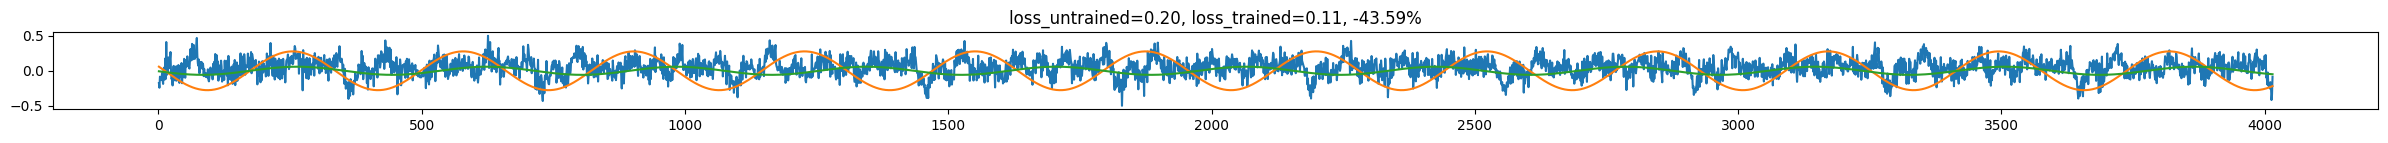

100%|██████████| 5/5 [00:00<00:00,  8.79it/s]


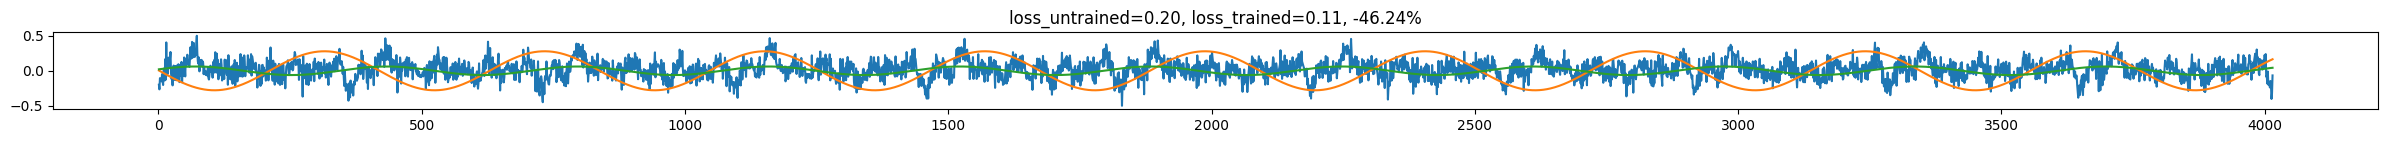

100%|██████████| 5/5 [00:00<00:00,  8.53it/s]


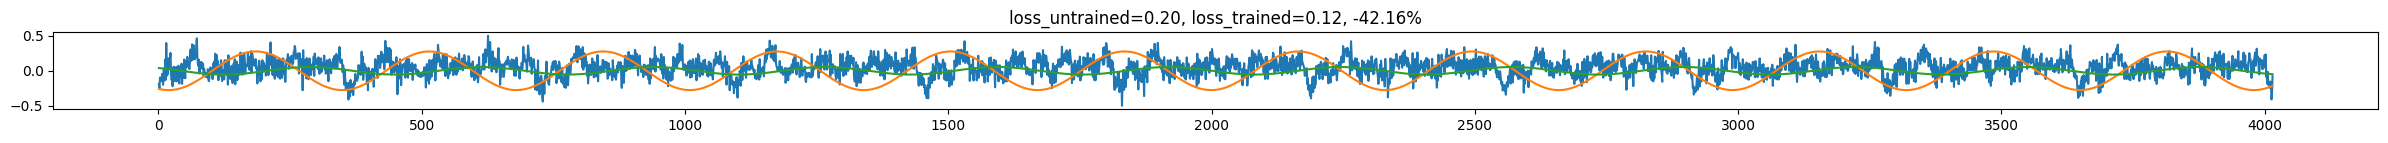

100%|██████████| 5/5 [00:00<00:00,  8.45it/s]


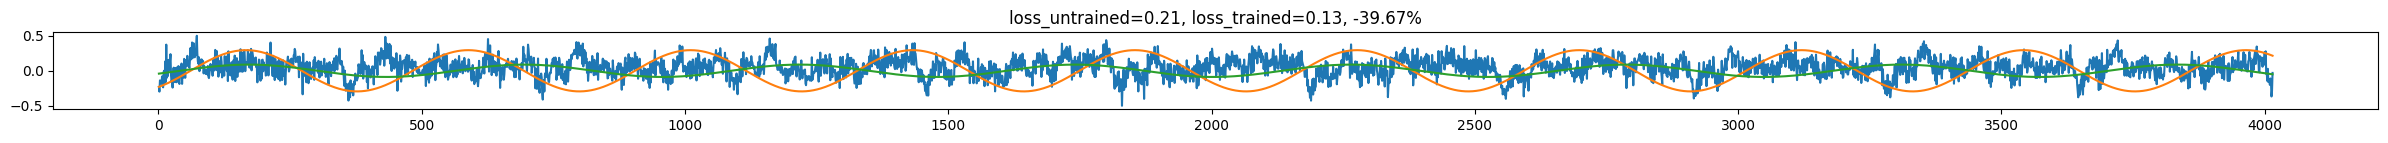

100%|██████████| 5/5 [00:00<00:00,  8.41it/s]


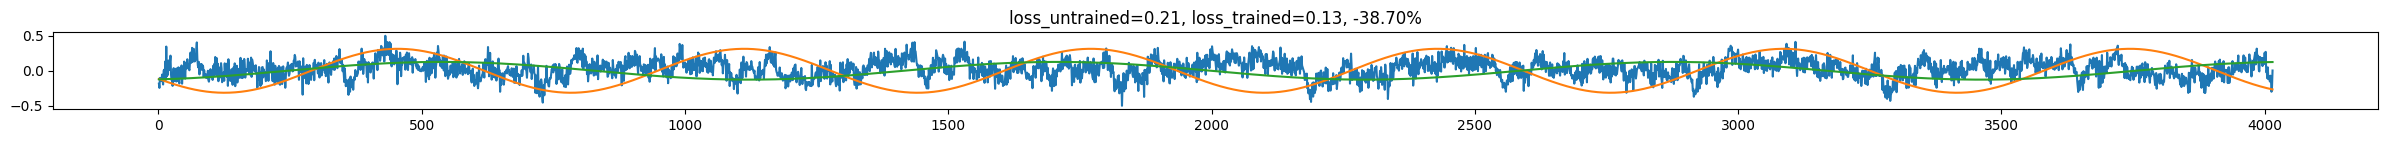

In [3]:
num_waves = 5
rolling_window = 121
learning_rate = 0.1
waves_params, residual = waves_residual_split(x_tensor, y_tensor, num_waves, rolling_window, learning_rate, device=device, wavelen='auto', plot=True)

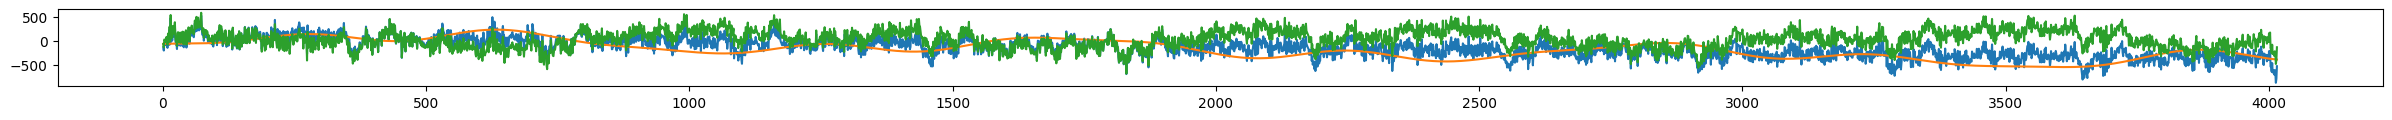

In [4]:
approximation = reconstruct_y(x_tensor, torch.zeros_like(y_tensor), waves_params)
residual = y_tensor - approximation
plt.figure(figsize=(30, 1))
plt.plot(x, y)
plt.plot(x, approximation.detach().cpu().numpy())
plt.plot(x, residual.detach().cpu().numpy())
plt.show()

# End